# Perceptron

---

![](https://upload.wikimedia.org/wikipedia/en/5/52/Mark_I_perceptron.jpeg)

*Mark I Perceptron machine, the first implementation of the perceptron algorithm*

This notebook implements the binary Perceptron in pure Python and compares it with the predefined `sklearn.linear_model.Perceptron`

---

## What is a Perceptron?

The Perceptron is one of the oldest and simplest supervised learning algorithms. It was invented by Frank Rosenblatt in 1957. You can think of it as a single artificial neuron that learns to classify data into two classes.

Given a data point $\mathbf{x} = (x_1, x_2, \ldots, x_d)$, the perceptron computes a weighted sum and produces a binary prediction:

$$z = \mathbf{w} \cdot \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + b$$

$$\hat{y} = \text{sign}(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

Where:
- $\mathbf{w}$ = weight vector (one weight per feature)
- $b$ = bias term (shifts the decision boundary)
- $\hat{y} \in \{-1, +1\}$ = predicted class label

---

## The Learning Rule

The perceptron updates its weights only when it makes a mistake. The update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} + y_i \cdot \mathbf{x}_i$$
$$b \leftarrow b + y_i$$

Where $y_i$ is the true label of the misclassified point.

If we predicted $-1$ but the true label is $+1$, we push the weights in the direction of $\mathbf{x}_i$. If we predicted $+1$ but the true label is $-1$, we push them in the opposite direction.

---

### Imports

In [34]:
!pip install numpy matplotlib scikit-learn

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

# This makes the random results repeatable every time we run the notebook
np.random.seed(42)

### Generate Dataset

We create a simple 2D dataset with two classes

In [36]:
X, y_raw = make_blobs(
    n_samples=100,
    centers=[(-2, -2), (2, 2)],
    cluster_std=0.9,
    random_state=42
)

y = np.where(y_raw == 0, -1, 1)

Visualization of the dataset

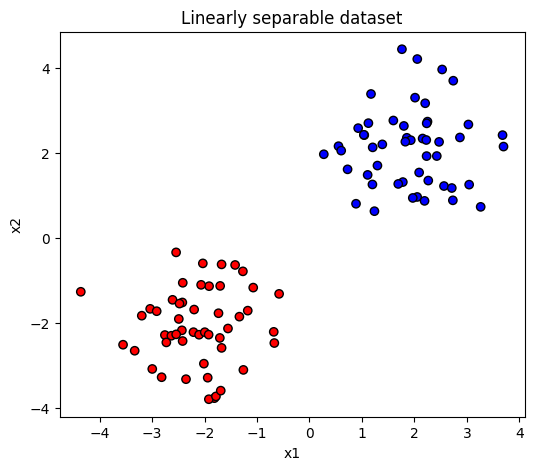

In [37]:
colors = ['red' if label == -1 else 'blue' for label in y]

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k')
plt.title('Linearly separable dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Define Perceptron Class

In [38]:
class Perceptron:
    def __init__(self, n_features, max_iter=100):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.max_iter = max_iter
        self.history = []

    def decision_function(self, X):
        X = np.asarray(X)
        return X @ self.weights + self.bias

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)

    def fit(self, X, y):
        for epoch in range(self.max_iter):
            errors = 0
            for xi, yi in zip(X, y):
                if yi * (np.dot(self.weights, xi) + self.bias) <= 0:
                    self.weights += yi * xi
                    self.bias += yi
                    errors += 1
            self.history.append(errors)
            if errors == 0:
                break
        return self

### Train the Perceptron

In [39]:
model = Perceptron(n_features=2, max_iter=10)
model.fit(X, y)

### Convergence Plot

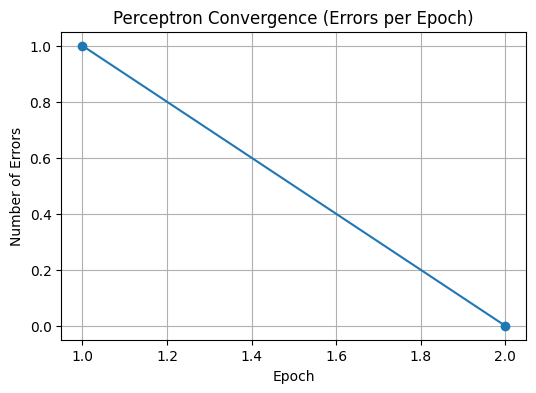

In [40]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(model.history)+1), model.history, marker='o')
plt.title("Perceptron Convergence (Errors per Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True)
plt.show()

### Margin Explanation

Distance from the closest point to the decision boundary.

- For a linear classifier with weights \(w\) and bias \(b\):

$$
\text{distance from point } x_i \text{ to boundary } = \frac{|w \cdot x_i + b|}{\|w\|}
$$

- The Perceptron finds a separating line, but it does not maximize the margin.
- We can visualize the margin by plotting lines parallel to the decision boundary that touch the closest positive and negative points.

In [41]:
def compute_margin(model, X, y):
    norm_w = np.linalg.norm(model.weights)
    if norm_w == 0:
        raise ValueError("Margin undefined because weights are zero.")
    signed_margins = y * (X @ model.weights + model.bias) / norm_w
    idx = np.argmin(signed_margins)
    return signed_margins[idx], X[idx]

margin, closest_point = compute_margin(model, X, y)
print(f"Perceptron margin: {margin:.3f}")
print(f"Closest point to boundary: {closest_point}")

Perceptron margin: 0.946
Closest point to boundary: [-0.57870847 -1.30930874]


### Decision Boundary Plot

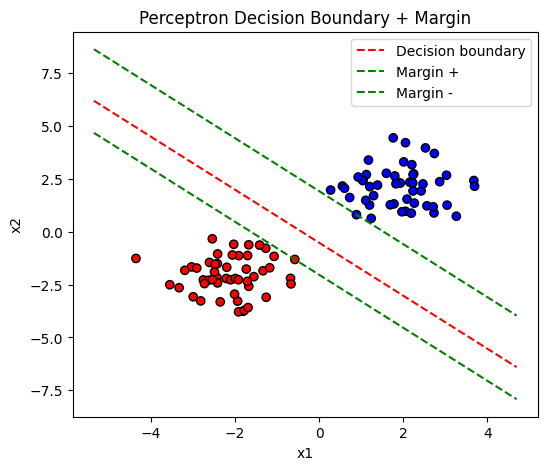

In [42]:
w = model.weights
b = model.bias

colors = ['red' if label == -1 else 'blue' for label in y]

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=colors, edgecolor='k')

slope = -w[0] / w[1]
intercept = -b / w[1]

x_vals = np.array([X[:,0].min() - 1, X[:,0].max() + 1])
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, 'r--', label="Decision boundary")

z = X @ w + b
distances = np.abs(X @ w + b) / np.linalg.norm(w)
closest_pos = X[y == 1][np.argmin(distances[y == 1])]
closest_neg = X[y == -1][np.argmin(distances[y == -1])]

y_margin_pos = slope * x_vals + (closest_pos[1] - slope*closest_pos[0])
y_margin_neg = slope * x_vals + (closest_neg[1] - slope*closest_neg[0])

plt.plot(x_vals, y_margin_pos, 'g--', label="Margin +")
plt.plot(x_vals, y_margin_neg, 'g--', label="Margin -")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary + Margin")
plt.legend()
plt.show()

### Comparison with Sklearn

We train `sklearn.linear_model.Perceptron` on the same dataset and with similar settings.

Even if the learned weights are not exactly identical, both models should produce a very similar separating boundary and the same predictions on this linearly separable dataset.

In [43]:
sk_model = SklearnPerceptron(
    max_iter=10,
    tol=None,
    shuffle=True,
    eta0=1.0,
    fit_intercept=True,
    penalty=None,
    random_state=42
)

sk_model.fit(X, y)

custom_preds = model.predict(X)
sklearn_preds = sk_model.predict(X)

custom_acc = accuracy_score(y, custom_preds)
sklearn_acc = accuracy_score(y, sklearn_preds)

print(f"Custom Perceptron accuracy:  {custom_acc:.3f}")
print(f"Sklearn Perceptron accuracy: {sklearn_acc:.3f}")
print()
print("Custom weights:", model.weights)
print("Custom bias:", model.bias)
print("Sklearn weights:", sk_model.coef_[0])
print("Sklearn bias:", sk_model.intercept_[0])

Custom Perceptron accuracy:  1.000
Sklearn Perceptron accuracy: 1.000

Custom weights: [2.42591386 1.93445398]
Custom bias: 1.0
Sklearn weights: [2.19268437 0.8788351 ]
Sklearn bias: 1.0


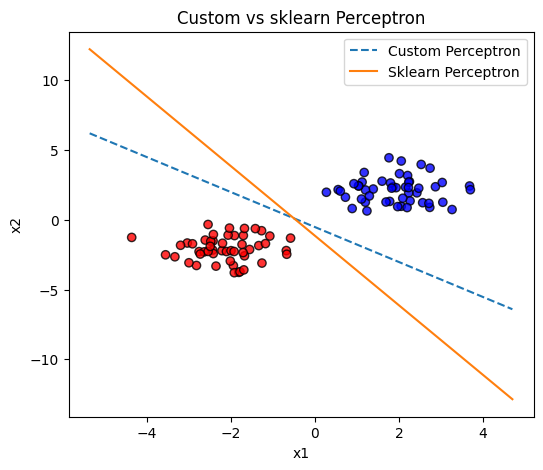

In [44]:
colors = ['red' if label == -1 else 'blue' for label in y]
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k', alpha=0.8)

x_vals = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

w1, b1 = model.weights, model.bias
y_vals_1 = -(w1[0] * x_vals + b1) / w1[1]
plt.plot(x_vals, y_vals_1, '--', label='Custom Perceptron')

w2, b2 = sk_model.coef_[0], sk_model.intercept_[0]
y_vals_2 = -(w2[0] * x_vals + b2) / w2[1]
plt.plot(x_vals, y_vals_2, '-', label='Sklearn Perceptron')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Custom vs sklearn Perceptron')
plt.legend()
plt.show()

### Non-separable Case

Now we make the classes overlap more, which means that there is no perfect straight line that separates all points.

In that case, the Perceptron usually does not converge to zero mistakes. It keeps updating until it reaches the maximum number of iterations.

In [ ]:
X_non, y_non_raw = make_blobs(
    n_samples=100,
    centers=[(-1, -1), (1, 1)],
    cluster_std=1.8,
    random_state=42
)

y_non = np.where(y_non_raw == 0, -1, 1)

model_non = Perceptron(n_features=X_non.shape[1], max_iter=50)
model_non.fit(X_non, y_non)

errors_non = model_non.history
y_non_pred = model_non.predict(X_non)
acc_non = accuracy_score(y_non, y_non_pred)

print('Weights:', model_non.weights)
print('Bias:', model_non.bias)
print('Epochs used:', len(errors_non))
print('Last 10 error counts:', errors_non[-10:])
print('Training accuracy:', acc_non)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(errors_non) + 1), errors_non, marker='o')
plt.title('Perceptron on non-separable data')
plt.xlabel('Epoch')
plt.ylabel('Number of mistakes')
plt.grid(True)
plt.show()